<a href="https://colab.research.google.com/github/aha2003/brain-tumor-classfication-FYP2025/blob/main/ResNet_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
import os
from google.colab import drive

drive.mount('/content/drive')

base_path = '/content/drive/My Drive/Kaggle_Datasets/mri-brain-tumor-dataset'
train_dir = os.path.join(base_path, 'Training')
test_dir = os.path.join(base_path, 'Testing')

IMG_SIZE = (224, 224)
BATCH_SIZE = 16


val_split_pct = 450 / 2935

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=val_split_pct, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=val_split_pct, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2870 files belonging to 4 classes.
Using 2430 files for training.
Found 2870 files belonging to 4 classes.
Using 440 files for validation.
Found 394 files belonging to 4 classes.


In [5]:
from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

def prepare_resnet_ds(ds):

    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds_resnet = prepare_resnet_ds(train_ds)
val_ds_resnet = prepare_resnet_ds(val_ds)
test_ds_resnet = prepare_resnet_ds(test_ds)

In [3]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50


base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


base_model.trainable = False


model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])


model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint_path = os.path.join(base_path, 'resnet50_phase1_best.keras')
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)

print("Starting ResNet-50 Phase 1: Feature Extraction...")
history_resnet = model_resnet.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Starting ResNet-50 Phase 1: Feature Extraction...
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 534s 3s/step - accuracy: 0.5523 - loss: 1.1323 - val_accuracy: 0.7955 - val_loss: 0.6269
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 498s 3s/step - accuracy: 0.7374 - loss: 0.6689 - val_accuracy: 0.8432 - val_loss: 0.4742
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 476s 3s/step - accuracy: 0.7963 - loss: 0.5387 - val_accuracy: 0.8545 - val_loss: 0.4001
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.8206 - loss: 0.4753 - val_accuracy: 0.8636 - val_loss: 0.3614
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 506s 3s/step - accuracy: 0.8399 - loss: 0.4264 - val_accuracy: 0.8909 - val_loss: 0.3303
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 478s 3s/step - accuracy: 0.8593 - loss: 0.3837 - val_accuracy: 0.8795 - val_loss: 0.3176
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.8626 - loss: 0.3532 - val_accuracy: 0.8977 - val_loss: 0.2929
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 519s 3s

In [4]:

model_path = os.path.join(base_path, 'resnet50_phase1_best.keras')
model_resnet = tf.keras.models.load_model(model_path)


model_resnet.layers[0].trainable = True
for layer in model_resnet.layers[0].layers[:-10]:
    layer.trainable = False


model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 4,728,452 (18.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint_path_p2 = os.path.join(base_path, 'resnet50_final_fine_tuned.keras')
checkpoint_p2 = ModelCheckpoint(checkpoint_path_p2, monitor='val_accuracy', save_best_only=True)

print("Starting ResNet-50 Phase 2: Fine-Tuning...")
history_resnet_p2 = model_resnet.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=10,
    callbacks=[early_stop, checkpoint_p2]
)

Starting ResNet-50 Phase 2: Fine-Tuning...
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 573s 4s/step - accuracy: 0.8901 - loss: 0.3075 - val_accuracy: 0.8955 - val_loss: 0.2617
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 547s 4s/step - accuracy: 0.9156 - loss: 0.2463 - val_accuracy: 0.9023 - val_loss: 0.2529
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 541s 4s/step - accuracy: 0.9325 - loss: 0.2128 - val_accuracy: 0.9114 - val_loss: 0.2413
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 539s 4s/step - accuracy: 0.9321 - loss: 0.1924 - val_accuracy: 0.9114 - val_loss: 0.2289
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 548s 4s/step - accuracy: 0.9560 - loss: 0.1536 - val_accuracy: 0.9159 - val_loss: 0.2225
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 542s 4s/step - accuracy: 0.9634 - loss: 0.1376 - val_accuracy: 0.9136 - val_loss: 0.2233
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 557s 4s/step - accuracy: 0.9749 - loss: 0.1113 - val_accuracy: 0.9227 - val_loss: 0.2159
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 547s 4s/step -

Running inference on test dataset for ResNet-50...

--- ResNet-50 Classification Report ---
                  precision    recall  f1-score   support

    glioma_tumor       0.96      0.26      0.41       100
meningioma_tumor       0.62      0.93      0.74       115
        no_tumor       0.74      0.94      0.83       105
 pituitary_tumor       0.95      0.78      0.86        74

        accuracy                           0.74       394
       macro avg       0.82      0.73      0.71       394
    weighted avg       0.80      0.74      0.70       394



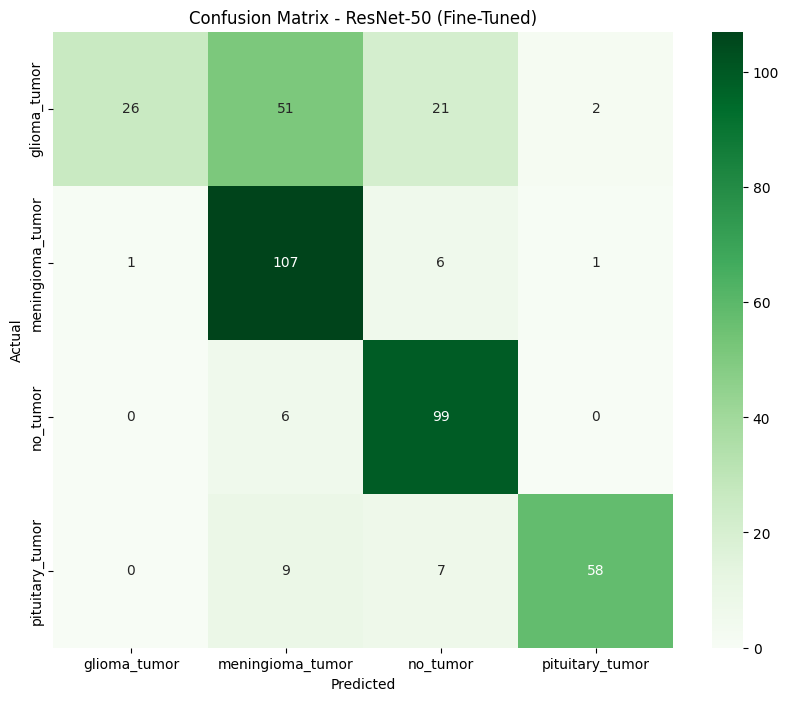

In [3]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_path = os.path.join(base_path, 'resnet50_final_fine_tuned.keras')
final_resnet_model = tf.keras.models.load_model(model_path)

class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

test_labels = []
test_preds = []

print("Running inference on test dataset for ResNet-50...")
for images, labels in test_ds_resnet: # Make sure to use the RESNET preprocessed test set
    preds = final_resnet_model.predict(images, verbose=0)
    test_labels.extend(np.argmax(labels, axis=1))
    test_preds.extend(np.argmax(preds, axis=1))

print("\n--- ResNet-50 Classification Report ---")
print(classification_report(test_labels, test_preds, target_names=class_names))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - ResNet-50 (Fine-Tuned)')
plt.show()

In [6]:
import tensorflow as tf
import os

resnet_path = os.path.join(base_path, 'resnet50_final_fine_tuned.keras')

model_resnet = tf.keras.models.load_model(resnet_path)

print("✓ ResNet-50 Fine-Tuned model successfully reloaded.")

✓ ResNet-50 Fine-Tuned model successfully reloaded.


Generating predictions for ResNet-50...


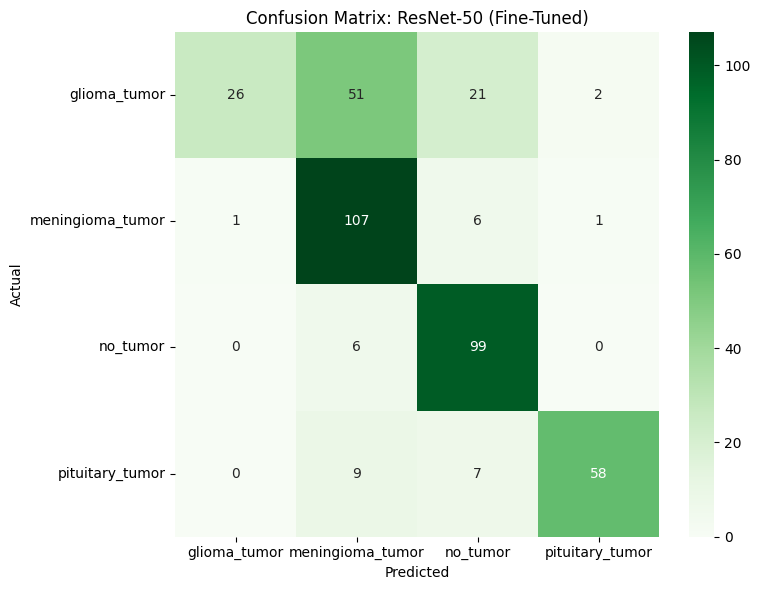

✓ ResNet-50 assets saved: resnet50_report.csv and resnet50_cm.png


In [7]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

def save_resnet_assets(model, test_dataset, save_path):
    print("Generating predictions for ResNet-50...")
    test_labels, test_preds = [], []

    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        test_labels.extend(np.argmax(labels, axis=1))
        test_preds.extend(np.argmax(preds, axis=1))

    report = classification_report(test_labels, test_preds, target_names=class_names, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(os.path.join(save_path, 'resnet50_report.csv'))

    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(test_labels, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: ResNet-50 (Fine-Tuned)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

    plt.savefig(os.path.join(save_path, 'resnet50_cm.png'), dpi=300)
    plt.show()
    print("✓ ResNet-50 assets saved: resnet50_report.csv and resnet50_cm.png")

# Execute
save_resnet_assets(model_resnet, test_ds_resnet, base_path)

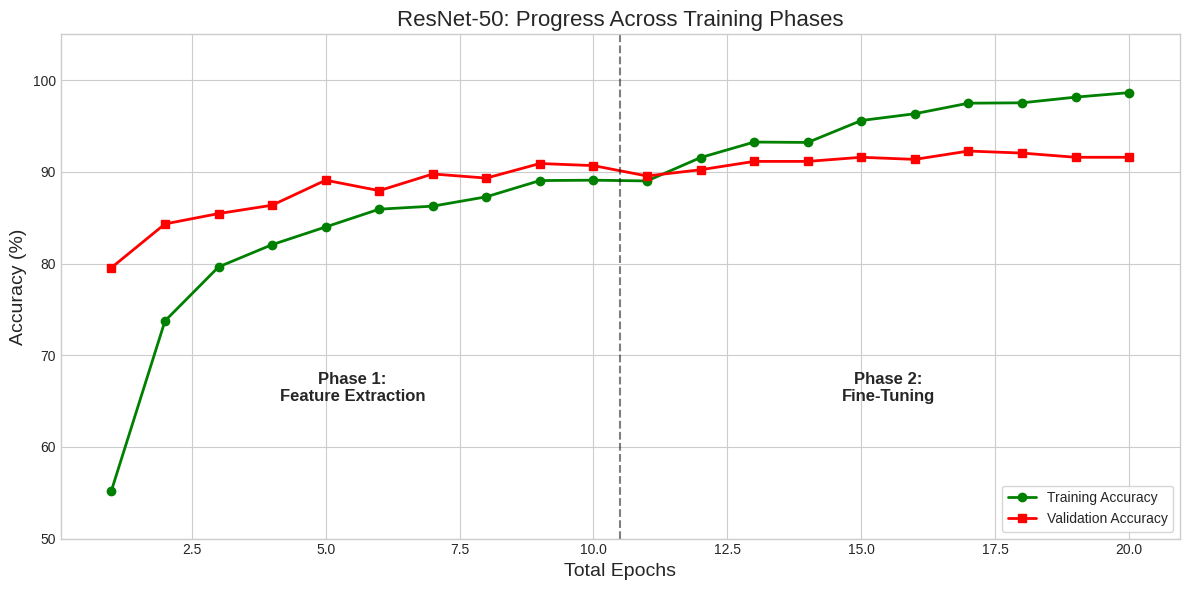

✓ Saved: resnet50_full_lifecycle.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

resnet_train_acc = [0.5523, 0.7374, 0.7963, 0.8206, 0.8399, 0.8593, 0.8626, 0.8728, 0.8905, 0.8909] + \
                   [0.8901, 0.9156, 0.9325, 0.9321, 0.9560, 0.9634, 0.9749, 0.9753, 0.9815, 0.9864]

resnet_val_acc = [0.7955, 0.8432, 0.8545, 0.8636, 0.8909, 0.8795, 0.8977, 0.8932, 0.9091, 0.9068] + \
                 [0.8955, 0.9023, 0.9114, 0.9114, 0.9159, 0.9136, 0.9227, 0.9205, 0.9159, 0.9159]

total_epochs = np.arange(1, 21)

plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(total_epochs, [x * 100 for x in resnet_train_acc], 'g-o', label='Training Accuracy', linewidth=2)
plt.plot(total_epochs, [x * 100 for x in resnet_val_acc], 'r-s', label='Validation Accuracy', linewidth=2)

plt.axvline(x=10.5, color='black', linestyle='--', alpha=0.5)
plt.text(5.5, 65, 'Phase 1:\nFeature Extraction', fontsize=12, ha='center', fontweight='bold')
plt.text(15.5, 65, 'Phase 2:\nFine-Tuning', fontsize=12, ha='center', fontweight='bold')

plt.title('ResNet-50: Progress Across Training Phases', fontsize=16)
plt.xlabel('Total Epochs', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.ylim(50, 105)
plt.legend(loc='lower right', frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'resnet50_full_lifecycle.png'), dpi=300)
plt.show()

print("✓ Saved: resnet50_full_lifecycle.png")